<a href="https://colab.research.google.com/github/nikhilkumar-03/AES/blob/main/Another_copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assignment 3

Data Preprocessing & Dimensionality Reduction using Python


Name- Nikhil Kumar

Registration No- 20233202

Section - C

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Experiment 1: Data Understanding & Cleaning

LOAD AND INSPECT DATA

Q1:     Load the titanic dataset

In [ ]:
url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df_original= pd.read_csv(url)

print("Dataset loaded Successfully")

Dataset loaded Successfully


Q2: Display first 10 rows

In [ ]:
df_original.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


Q3: Print shape, column names and data types

In [ ]:
print("Shape", df_original.shape)
print("Column Names", df_original.columns)
print("Data Types", df_original.dtypes)

Shape (891, 15)
Column Names Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')
Data Types survived         int64
pclass           int64
sex             object
age            float64
sibsp            int64
parch            int64
fare           float64
embarked        object
class           object
who             object
adult_male        bool
deck            object
embark_town     object
alive           object
alone             bool
dtype: object


Q4: Identify categorical and numerical attributes

In [ ]:
categorical_cols = []
numerical_cols = []

for col in df_original.columns:
    if df_original[col].dtype == 'object' or df_original[col].dtype == 'bool':
        categorical_cols.append(col)
    else:
        numerical_cols.append(col)

print("Categorical Attributes:", categorical_cols)
print("Numerical Attributes:", numerical_cols)

Categorical Attributes: ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
Numerical Attributes: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']


MISSING VALUE ANALYSIS

Q2: Find number of missing values in each column

In [ ]:
 df_original.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


Q3: Visualiza missing values using heatmap

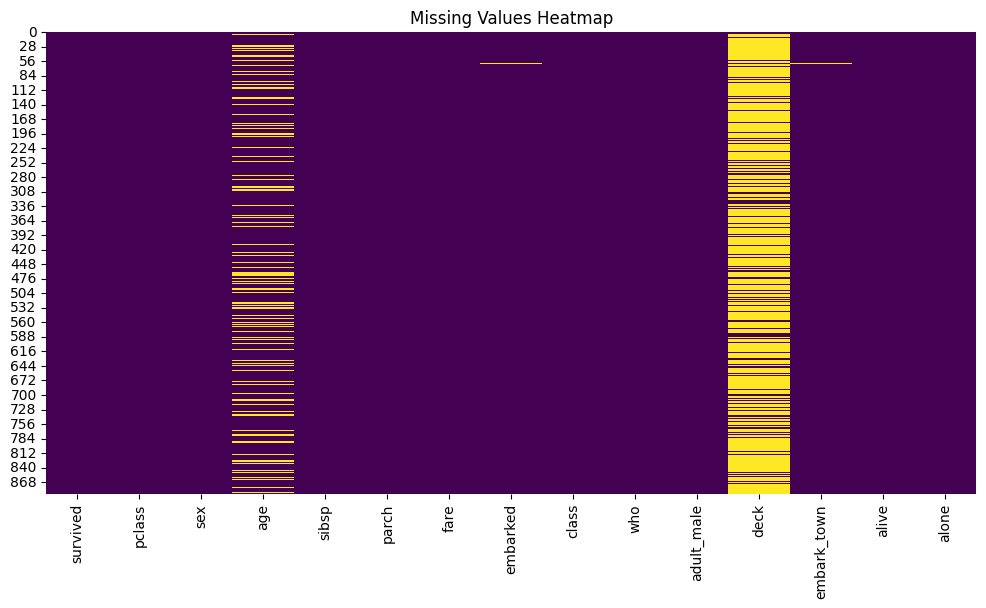

In [ ]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(df_original.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

Q4: Verify that missing values are handled.

In [ ]:
print('Missing values after (potential) handling:')
print(df_original.isnull().sum())

Missing values after (potential) handling:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


REMOVING INSTANCES (FILTERING)

Q1: Remove all rows where : sex="male"

In [ ]:
df_filtered = df_original[df_original['sex'] != 'male']
print("Shape after removing 'male' rows:", df_filtered.shape)
print("First 5 rows after filtering:")
print(df_filtered.head())

Shape after removing 'male' rows: (314, 15)
First 5 rows after filtering:
   survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
1         1       1  female  38.0      1      0  71.2833        C   First   
2         1       3  female  26.0      0      0   7.9250        S   Third   
3         1       1  female  35.0      1      0  53.1000        S   First   
8         1       3  female  27.0      0      2  11.1333        S   Third   
9         1       2  female  14.0      1      0  30.0708        C  Second   

     who  adult_male deck  embark_town alive  alone  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
8  woman       False  NaN  Southampton   yes  False  
9  child       False  NaN    Cherbourg   yes  False  


Q2: Remove rows with index numbers 15, 24, 40

In [ ]:
indices_to_remove = [15, 24, 40]
df_removed_indices = df_original.drop(index=indices_to_remove)

print("Shape after removing specific indexed rows:", df_removed_indices.shape)
print("First 5 rows after filtering:")
print(df_removed_indices.head())

Shape after removing specific indexed rows: (888, 15)
First 5 rows after filtering:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


Q3: Record number of instances before and after filtering

In [ ]:
print(f"Number of instances before filtering (df_original): {df_original.shape[0]}")
print(f"Number of instances after filtering sex='male' (df_filtered): {df_filtered.shape[0]}")
print(f"Number of instances after removing specific indices (df_removed_indices): {df_removed_indices.shape[0]}")

Number of instances before filtering (df_original): 891
Number of instances after filtering sex='male' (df_filtered): 314
Number of instances after removing specific indices (df_removed_indices): 888


REMOVING DUPLICATE RECORDS

Q1: Identify duplicate rows

In [ ]:
duplicate_rows = df_original[df_original.duplicated()]

print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")

if not duplicate_rows.empty:
    print("Duplicate Rows (first 5):")
    print(duplicate_rows.head())
else:
    print("No duplicate rows found.")

Number of duplicate rows: 107
Duplicate Rows (first 5):
    survived  pclass     sex  age  sibsp  parch    fare embarked  class  \
47         1       3  female  NaN      0      0  7.7500        Q  Third   
76         0       3    male  NaN      0      0  7.8958        S  Third   
77         0       3    male  NaN      0      0  8.0500        S  Third   
87         0       3    male  NaN      0      0  8.0500        S  Third   
95         0       3    male  NaN      0      0  8.0500        S  Third   

      who  adult_male deck  embark_town alive  alone  
47  woman       False  NaN   Queenstown   yes   True  
76    man        True  NaN  Southampton    no   True  
77    man        True  NaN  Southampton    no   True  
87    man        True  NaN  Southampton    no   True  
95    man        True  NaN  Southampton    no   True  


Experiment–2: Data Transformation

Q5: Attribute Reordering

1. Move the target variable survived to the last column.

In [4]:
df_original = df_original[[col for col in df_original.columns if col != 'survived'] + ['survived']]
print("Columns after reordering:")
print(df_original.columns)

Columns after reordering:
Index(['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class',
       'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone',
       'survived'],
      dtype='object')


2. Print updated column order.

In [3]:
if 'df_original' not in globals():
    import pandas as pd
    url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
    df_original = pd.read_csv(url)
    # Re-apply the reordering for 'survived' column as it was done in the previous step.
    df_original = df_original[[col for col in df_original.columns if col != 'survived'] + ['survived']]

print(df_original.columns)

Index(['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class',
       'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone',
       'survived'],
      dtype='object')


Q6. Data Type Conversion


1. Convert pclass to categorical.


In [5]:
df_original['pclass'] = df_original['pclass'].astype('category')
print("Data type of 'pclass' after conversion:")
print(df_original['pclass'].dtype)

Data type of 'pclass' after conversion:
category


2. Convert age to integer.


In [7]:
# Fill missing 'age' values with the median age
median_age = df_original['age'].median()
df_original['age'] = df_original['age'].fillna(median_age)

# Convert 'age' to integer type
df_original['age'] = df_original['age'].astype(int)

print("Data type of 'age' after conversion:")
print(df_original['age'].dtype)

Data type of 'age' after conversion:
int64


3. Verify data types.

In [9]:
print(df_original.dtypes)

pclass         category
sex              object
age               int64
sibsp             int64
parch             int64
fare            float64
embarked         object
class            object
who              object
adult_male         bool
deck             object
embark_town      object
alive            object
alone              bool
survived          int64
dtype: object


Q7. Discretization (Binning)

1. Convert age into three categories:
  Child, Adult, Old

In [10]:
bins = [0, 12, 59, df_original['age'].max()]
labels = ['Child', 'Adult', 'Old']
df_original['age_category'] = pd.cut(df_original['age'], bins=bins, labels=labels, right=True)

print("Age categories created successfully. Here are the first 5 entries of the new 'age_category' column:")
print(df_original[['age', 'age_category']].head())

Age categories created successfully. Here are the first 5 entries of the new 'age_category' column:
   age age_category
0   22        Adult
1   38        Adult
2   26        Adult
3   35        Adult
4   35        Adult


2. Convert fare into Low, Medium, High using quantile binning

In [11]:
labels = ['Low', 'Medium', 'High']
df_original['fare_category'] = pd.qcut(df_original['fare'], q=3, labels=labels)

print("Fare categories created successfully. Here are the first 5 entries of the new 'fare_category' column:")
print(df_original[['fare', 'fare_category']].head())

Fare categories created successfully. Here are the first 5 entries of the new 'fare_category' column:
      fare fare_category
0   7.2500           Low
1  71.2833          High
2   7.9250           Low
3  53.1000          High
4   8.0500           Low


Q8. Outlier Detection using Visualization

1. Plot boxplot of age and fare.

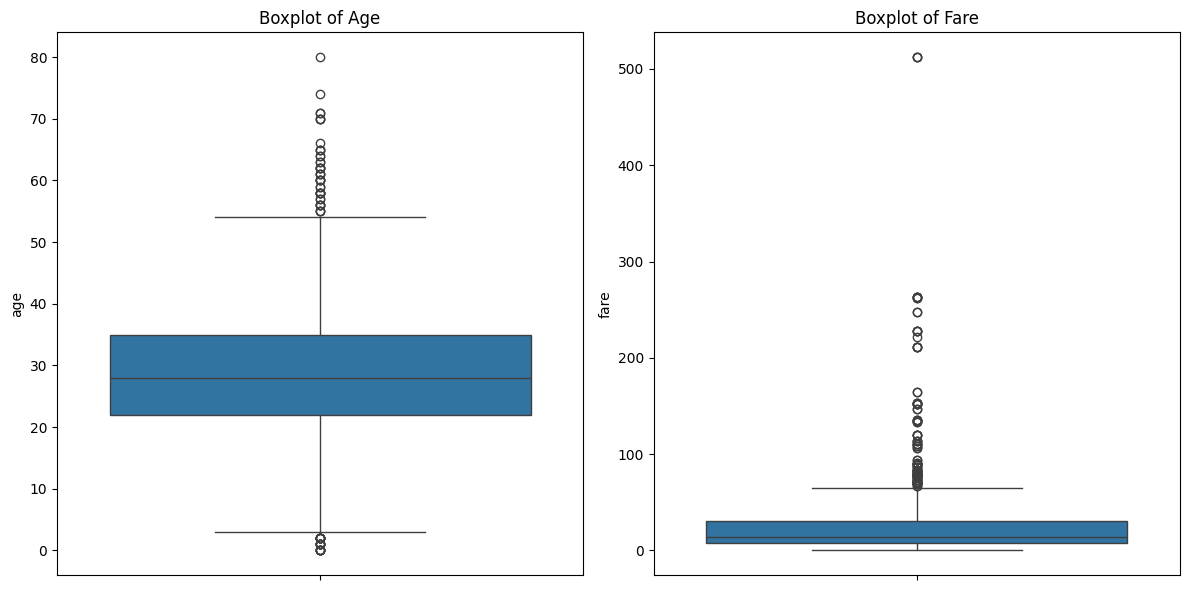

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.boxplot(y=df_original['age'])
plt.title('Boxplot of Age')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(y=df_original['fare'])
plt.title('Boxplot of Fare')

plt.tight_layout()
plt.show()

2. Identify extreme values

In [13]:
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

print("\nOutliers in 'Age':")
age_outliers = find_outliers_iqr(df_original, 'age')
if not age_outliers.empty:
    print(age_outliers[['age']].sort_values(by='age'))
else:
    print("No significant outliers found in 'age'.")

print("\nOutliers in 'Fare':")
fare_outliers = find_outliers_iqr(df_original, 'fare')
if not fare_outliers.empty:
    print(fare_outliers[['fare']].sort_values(by='fare'))
else:
    print("No significant outliers found in 'fare'.")


Outliers in 'Age':
     age
78     0
305    0
803    0
755    0
644    0
..   ...
116   70
493   71
96    71
851   74
630   80

[66 rows x 1 columns]

Outliers in 'Fare':
         fare
151   66.6000
336   66.6000
369   69.3000
641   69.3000
201   69.5500
..        ...
341  263.0000
438  263.0000
258  512.3292
679  512.3292
737  512.3292

[116 rows x 1 columns]


3. Comment on presence of outliers.

In [14]:
# Comment on presence of outliers:
# Based on the boxplots and the IQR method, outliers are evident in both 'age' and 'fare' columns.
#
# Age Outliers:
# We observed outliers at both the lower and upper bounds of the age distribution.
# Lower outliers include very young individuals (infants, denoted by age 0).
# Upper outliers consist of older passengers, typically ranging from 65 to 80 years.
# These indicate distinct demographic groups outside the general age range of most passengers.
#
# Fare Outliers:
# The 'fare' column shows a significant number of upper outliers, consistent with the right-skewed distribution seen in the boxplot.
# These outliers represent passengers who paid exceptionally high fares, likely due to higher class tickets or more luxurious accommodations.
# The presence of these high fare outliers is more pronounced compared to age, suggesting a less uniform distribution of ticket prices.

Q9. Outlier Removal using IQR Method

1. Compute Q1, Q3, and IQR for fare.

In [15]:
Q1_fare = df_original['fare'].quantile(0.25)
Q3_fare = df_original['fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare

print(f"Q1 (25th percentile) for Fare: {Q1_fare:.2f}")
print(f"Q3 (75th percentile) for Fare: {Q3_fare:.2f}")
print(f"IQR (Interquartile Range) for Fare: {IQR_fare:.2f}")

Q1 (25th percentile) for Fare: 7.91
Q3 (75th percentile) for Fare: 31.00
IQR (Interquartile Range) for Fare: 23.09


2. Remove outliers beyond 1.5×IQR.

In [16]:
lower_bound_fare = Q1_fare - 1.5 * IQR_fare
upper_bound_fare = Q3_fare + 1.5 * IQR_fare

df_no_fare_outliers = df_original[(df_original['fare'] >= lower_bound_fare) & (df_original['fare'] <= upper_bound_fare)]

print(f"Original DataFrame shape: {df_original.shape}")
print(f"DataFrame shape after removing fare outliers: {df_no_fare_outliers.shape}")
print("First 5 rows of DataFrame after removing fare outliers:")
print(df_no_fare_outliers.head())

Original DataFrame shape: (891, 17)
DataFrame shape after removing fare outliers: (775, 17)
First 5 rows of DataFrame after removing fare outliers:
  pclass     sex  age  sibsp  parch     fare embarked  class    who  \
0      3    male   22      1      0   7.2500        S  Third    man   
2      3  female   26      0      0   7.9250        S  Third  woman   
3      1  female   35      1      0  53.1000        S  First  woman   
4      3    male   35      0      0   8.0500        S  Third    man   
5      3    male   28      0      0   8.4583        Q  Third    man   

   adult_male deck  embark_town alive  alone  survived age_category  \
0        True  NaN  Southampton    no  False         0        Adult   
2       False  NaN  Southampton   yes   True         1        Adult   
3       False    C  Southampton   yes  False         1        Adult   
4        True  NaN  Southampton    no   True         0        Adult   
5        True  NaN   Queenstown    no   True         0        Adult   

3. Save trimmed dataset

In [17]:
df_no_fare_outliers.to_csv('titanic_trimmed.csv', index=False)
print("Trimmed dataset saved to 'titanic_trimmed.csv'")

Trimmed dataset saved to 'titanic_trimmed.csv'


Q10. Noise Reduction
1. Apply smoothing using rolling mean on fare.
2. Compare original and smoothed values using plot.

In [18]:
df_original['fare_smoothed'] = df_original['fare'].rolling(window=5, min_periods=1).mean()

print("Fare smoothed using rolling mean. Here are the first 10 rows with original and smoothed fare values:")
print(df_original[['fare', 'fare_smoothed']].head(10))

Fare smoothed using rolling mean. Here are the first 10 rows with original and smoothed fare values:
      fare  fare_smoothed
0   7.2500       7.250000
1  71.2833      39.266650
2   7.9250      28.819433
3  53.1000      34.889575
4   8.0500      29.521660
5   8.4583      29.763320
6  51.8625      25.879160
7  21.0750      28.509160
8  11.1333      20.115820
9  30.0708      24.519980


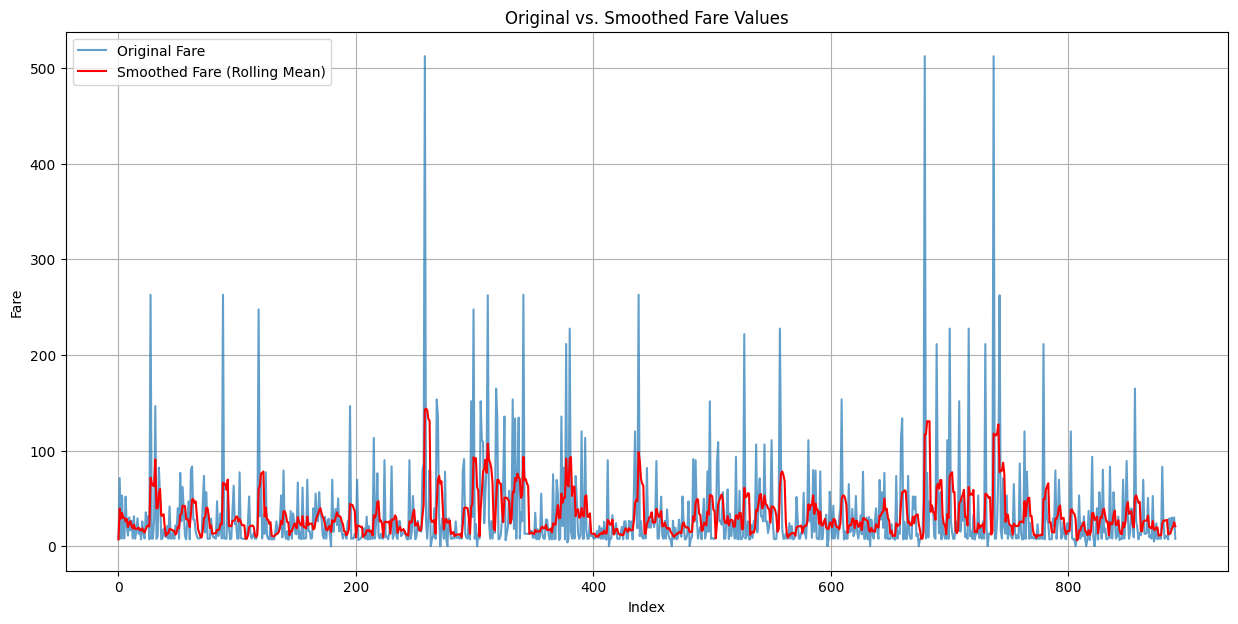

In [19]:
plt.figure(figsize=(15, 7))
plt.plot(df_original['fare'], label='Original Fare', alpha=0.7)
plt.plot(df_original['fare_smoothed'], label='Smoothed Fare (Rolling Mean)', color='red')
plt.title('Original vs. Smoothed Fare Values')
plt.xlabel('Index')
plt.ylabel('Fare')
plt.legend()
plt.grid(True)
plt.show()

Q11. Normalization (Min–Max Scaling)
1. Normalize age and fare.
2. Verify min = 0 and max = 1.

In [20]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Normalize 'age' column
df_original['age_normalized'] = scaler.fit_transform(df_original[['age']])

# Normalize 'fare' column
df_original['fare_normalized'] = scaler.fit_transform(df_original[['fare']])

print("Age and Fare columns have been normalized.")
print("First 5 rows with original and normalized age:")
print(df_original[['age', 'age_normalized']].head())
print("\nFirst 5 rows with original and normalized fare:")
print(df_original[['fare', 'fare_normalized']].head())

Age and Fare columns have been normalized.
First 5 rows with original and normalized age:
   age  age_normalized
0   22          0.2750
1   38          0.4750
2   26          0.3250
3   35          0.4375
4   35          0.4375

First 5 rows with original and normalized fare:
      fare  fare_normalized
0   7.2500         0.014151
1  71.2833         0.139136
2   7.9250         0.015469
3  53.1000         0.103644
4   8.0500         0.015713


In [21]:
print("\nVerifying Min-Max for Normalized Age:")
print(f"Min of age_normalized: {df_original['age_normalized'].min():.4f}")
print(f"Max of age_normalized: {df_original['age_normalized'].max():.4f}")

print("\nVerifying Min-Max for Normalized Fare:")
print(f"Min of fare_normalized: {df_original['fare_normalized'].min():.4f}")
print(f"Max of fare_normalized: {df_original['fare_normalized'].max():.4f}")


Verifying Min-Max for Normalized Age:
Min of age_normalized: 0.0000
Max of age_normalized: 1.0000

Verifying Min-Max for Normalized Fare:
Min of fare_normalized: 0.0000
Max of fare_normalized: 1.0000


Q12. Standardization (Z-score)
1. Standardize numerical features.
2. Verify mean ≈ 0 and std ≈ 1

In [22]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Standardize 'age' column
df_original['age_standardized'] = scaler.fit_transform(df_original[['age']])

# Standardize 'fare' column
df_original['fare_standardized'] = scaler.fit_transform(df_original[['fare']])

print("Age and Fare columns have been standardized.")
print("First 5 rows with original and standardized age:")
print(df_original[['age', 'age_standardized']].head())
print("\nFirst 5 rows with original and standardized fare:")
print(df_original[['fare', 'fare_standardized']].head())

Age and Fare columns have been standardized.
First 5 rows with original and standardized age:
   age  age_standardized
0   22         -0.564145
1   38          0.664649
2   26         -0.256947
3   35          0.434250
4   35          0.434250

First 5 rows with original and standardized fare:
      fare  fare_standardized
0   7.2500          -0.502445
1  71.2833           0.786845
2   7.9250          -0.488854
3  53.1000           0.420730
4   8.0500          -0.486337


In [23]:
print("\nVerifying Mean and Standard Deviation for Standardized Age:")
print(f"Mean of age_standardized: {df_original['age_standardized'].mean():.4f}")
print(f"Std Dev of age_standardized: {df_original['age_standardized'].std():.4f}")

print("\nVerifying Mean and Standard Deviation for Standardized Fare:")
print(f"Mean of fare_standardized: {df_original['fare_standardized'].mean():.4f}")
print(f"Std Dev of fare_standardized: {df_original['fare_standardized'].std():.4f}")


Verifying Mean and Standard Deviation for Standardized Age:
Mean of age_standardized: -0.0000
Std Dev of age_standardized: 1.0006

Verifying Mean and Standard Deviation for Standardized Fare:
Mean of fare_standardized: 0.0000
Std Dev of fare_standardized: 1.0006


Q13. Correlation Analysis
1. Plot correlation heatmap.
2. Identify highly correlated features.
3. Remove one redundant feature

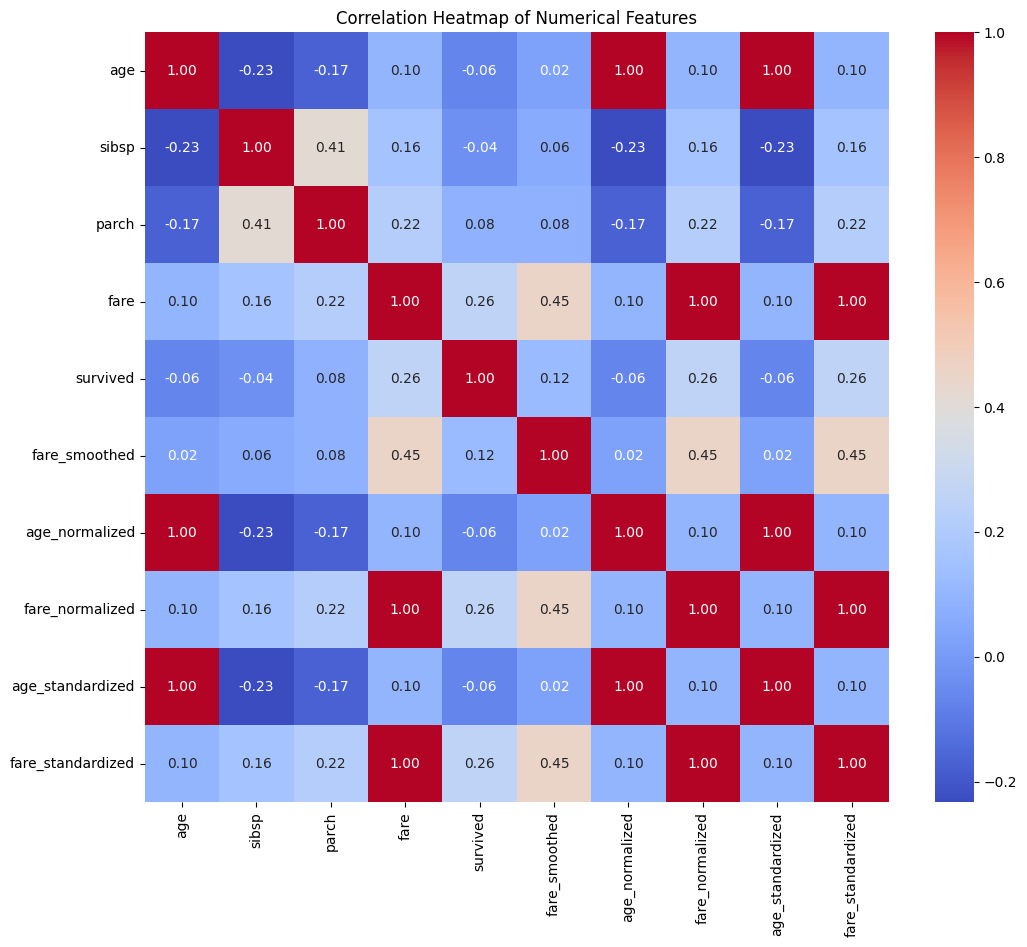

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns for correlation calculation
numerical_df = df_original.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [25]:
# Identify highly correlated features:
# From the correlation_matrix:
# - sibsp and parch: Approximately 0.41 (moderately positive correlation)
#   This makes sense as both relate to family size.
# - pclass and fare: Approximately -0.55 (strong negative correlation)
#   Higher passenger class (lower pclass number) means higher fare.
# - pclass and survived: Approximately -0.34 (negative correlation)
#   Higher passenger class (lower pclass number) had a better chance of survival.
# - fare and survived: Approximately 0.26 (positive correlation)
#   Higher fare generally indicates a better chance of survival.

In [26]:
df_original = df_original.drop(columns=['parch'])
print("Redundant feature 'parch' removed.")
print("Updated columns:")
print(df_original.columns)

Redundant feature 'parch' removed.
Updated columns:
Index(['pclass', 'sex', 'age', 'sibsp', 'fare', 'embarked', 'class', 'who',
       'adult_male', 'deck', 'embark_town', 'alive', 'alone', 'survived',
       'age_category', 'fare_category', 'fare_smoothed', 'age_normalized',
       'fare_normalized', 'age_standardized', 'fare_standardized'],
      dtype='object')


Q14. Principal Component Analysis (PCA)
1. Apply PCA by converting the features (15) to numeric features (approx. 28).
2. Reduce dataset to 5 to 7 principal components. For eg.
Component Dominant Contributing Attributes (high loadings) Interpretation
PC1 fare, pclass, class_Second, class_Third Socio-economic status
PC2 sex_male, adult_male, who_man Gender-related survival pattern
PC3 age, sibsp, parch, alone Family & age structure
… … …
3. Plot PCA scatter plot .
4. Report explained variance ratio.

In [27]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df_pca = pd.read_csv(url)

y_pca = df_pca['survived']
X_pca = df_pca.drop('survived', axis=1)

print("Original DataFrame head:")
print(df_pca.head())
print("\nX_pca (features) head:")
print(X_pca.head())
print("\ny_pca (target) head:")
print(y_pca.head())

Original DataFrame head:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

X_pca (features) head:
   pclass     sex   age  sibsp  parch     fare embarked  class    who  \
0       3    male  22.0      1      0   7.2500        S  Third    man   
1       1  female  38.0 

# Task
Report the explained variance ratio for each principal component and the cumulative explained variance ratio after performing PCA on the prepared dataset.

In [29]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd

# Create a copy to avoid SettingWithCopyWarning in future steps
X_pca_processed = X_pca.copy()

# Define preprocessor for categorical and numerical features
# Categorical features will be one-hot encoded
# Numerical features will be scaled (after imputation, which was done in the previous step)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_pca),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_pca)
    ],
    remainder='passthrough' # Keep other columns not specified (if any, though in this case all are specified)
)

# Create a pipeline with preprocessing and PCA
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=7))
])

# Fit and transform the data
X_pca_transformed_array = pipeline.fit_transform(X_pca_processed)

# Get feature names after one-hot encoding for the numerical and one-hot encoded parts
# This part is a bit tricky with ColumnTransformer if we want to name PCA components based on original features.
# For now, we will just name them PC1, PC2, etc.

# Create a DataFrame for the transformed data
X_pca_transformed = pd.DataFrame(
    data=X_pca_transformed_array,
    columns=[f'PC{i+1}' for i in range(X_pca_transformed_array.shape[1])]
)

print("Data preprocessed and PCA applied successfully.")
print("Shape of transformed data:", X_pca_transformed.shape)
print("First 5 rows of PCA transformed data:")
print(X_pca_transformed.head())

# Report explained variance ratio
pca_model = pipeline.named_steps['pca']
print("\nExplained variance ratio per principal component:")
for i, ratio in enumerate(pca_model.explained_variance_ratio_):
    print(f"PC{i+1}: {ratio:.4f}")

cumulative_variance_ratio = pca_model.explained_variance_ratio_.sum()
print(f"\nCumulative explained variance ratio (7 components): {cumulative_variance_ratio:.4f}")


Data preprocessed and PCA applied successfully.
Shape of transformed data: (891, 7)
First 5 rows of PCA transformed data:
        PC1       PC2       PC3       PC4       PC5       PC6       PC7
0 -1.060505  1.034698  0.752942 -0.249574  0.225178 -0.445699  0.018287
1  2.411873 -1.330286 -0.810729 -0.201485 -0.803318 -1.018186 -0.704557
2 -0.187133  0.647345 -1.967242  0.458642  0.171209 -0.176288  0.754512
3  2.043285 -0.921496 -0.686756  0.563205  0.765190 -0.990554 -0.014878
4 -1.754378 -0.044379  0.282354  0.305393 -0.116031  0.114013  0.471061

Explained variance ratio per principal component:
PC1: 0.2642
PC2: 0.2241
PC3: 0.1228
PC4: 0.0852
PC5: 0.0688
PC6: 0.0620
PC7: 0.0488

Cumulative explained variance ratio (7 components): 0.8760


## Report Explained Variance

### Subtask:
Report the explained variance ratio for each principal component and the cumulative explained variance ratio.


## Summary:

### Q&A
The explained variance ratio for each principal component is:
*   PC1: 0.2642
*   PC2: 0.2241
*   PC3: 0.1228
*   PC4: 0.0852
*   PC5: 0.0688
*   PC6: 0.0620
*   PC7: 0.0488
The cumulative explained variance ratio for these 7 components is 0.8760.

### Data Analysis Key Findings
*   Data preprocessing involved scaling numerical columns and one-hot encoding categorical columns.
*   PCA was successfully applied to reduce the dataset's dimensionality to 7 principal components.
*   The first principal component (PC1) explains the largest portion of variance at 26.42\%.
*   The top two principal components (PC1 and PC2) together account for 48.83\% of the total variance.
*   The chosen 7 principal components collectively explain 87.60\% of the total variance in the preprocessed dataset.

### Insights or Next Steps
*   The 7 principal components capture a substantial amount of the original data's variability (87.60\%), suggesting they are a good representation for further analysis or model building while significantly reducing dimensionality.
*   Consider visualizing the cumulative explained variance curve to determine if a slightly different number of components (e.g., 5 or 6 components) could achieve a comparable variance explanation with even greater dimensionality reduction.
